### **Step** 1: Install *Dependencies*

In [1]:
!pip install -q transformers datasets accelerate

zsh:1: command not found: pip


### **Step** 2: Load GSM8K Subset*



In [2]:
from datasets import load_dataset

# Load a subset for faster experiments
gsm8k = load_dataset("gsm8k", "main", split="test[:50]")


/Users/shobhitagnihotri/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

main/train-00000-of-00001.parquet:   0%|          | 0.00/2.31M [00:00<?, ?B/s]

main/test-00000-of-00001.parquet:   0%|          | 0.00/419k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/7473 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1319 [00:00<?, ? examples/s]

### Step 2.1: Load SVAMP Dataset

In [3]:
!git clone https://github.com/arkilpatel/SVAMP.git

import json
from datasets import Dataset

# Load the file from the cloned folder
with open("SVAMP/SVAMP.json", "r") as f:
    raw_data = json.load(f)

# Convert to HuggingFace-style dataset
svamp = Dataset.from_list([
    {"Question": item["Body"], "Answer": str(item["Answer"])}
    for item in raw_data
])


Cloning into 'SVAMP'...
remote: Enumerating objects: 397, done.
remote: Counting objects: 100% (62/62), done.
remote: Compressing objects: 100% (35/35), done.
remote: Total 397 (delta 37), reused 27 (delta 27), pack-reused 335 (from 1)
Receiving objects: 100% (397/397), 1.63 MiB | 1.43 MiB/s, done.
Resolving deltas: 100% (186/186), done.


In [4]:
svamp_subset = svamp.select(range(50))


### **Step** 3: Define Few-Shot CoT Prompt

In [5]:
# ✍️ Few-shot Chain of Thought prompt examples
few_shot_prefix = """Q: Emily has 3 apples. Her friend gives her 2 more. How many apples does Emily have now?
A: Emily starts with 3 apples. Her friend gives her 2 more. So, 3 + 2 = 5. The answer is 5.

Q: A pen costs 2 dollars. John buys 4 pens. How much does he pay?
A: Each pen costs 2 dollars. John buys 4 pens. So, 2 × 4 = 8. The answer is 8.

Q: Jake read 5 pages on Monday and 7 pages on Tuesday. How many pages did he read in total?
A: Jake read 5 pages on Monday and 7 on Tuesday. So, 5 + 7 = 12. The answer is 12.
"""


### **Step** 4: Define the function used to evaluate the models




In [6]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM, pipeline
import torch
import re

def evaluate_model_fewshot(model_id):
    print(f"Evaluating {model_id} with few-shot CoT...")
    tokenizer = AutoTokenizer.from_pretrained(model_id)
    model = AutoModelForSeq2SeqLM.from_pretrained(model_id)
    pipe = pipeline("text2text-generation", model=model, tokenizer=tokenizer, max_new_tokens=128)

    correct = 0
    total = 0

    for sample in gsm8k:
        question = sample["question"]
        gt_answer = sample["answer"].split("####")[-1].strip()

        prompt = few_shot_prefix + f"Q: {question}\nA:"
        output = pipe(prompt)[0]["generated_text"]

        match = re.search(r"(\d+(?:\.\d+)?)", output.replace(",", ""))
        if match:
            pred = match.group(1)
            if pred == gt_answer:
                correct += 1
        total += 1

    acc = correct / total
    print(f"Accuracy: {acc:.2%}")
    return acc


### **Step** 5: Run Across Model Sizes and Plot


Evaluating google/flan-t5-small with few-shot CoT...


tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

...

config.json:   0%|          | 0.00/662 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/3.13G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

Device set to use mps:0


Accuracy: 2.00%


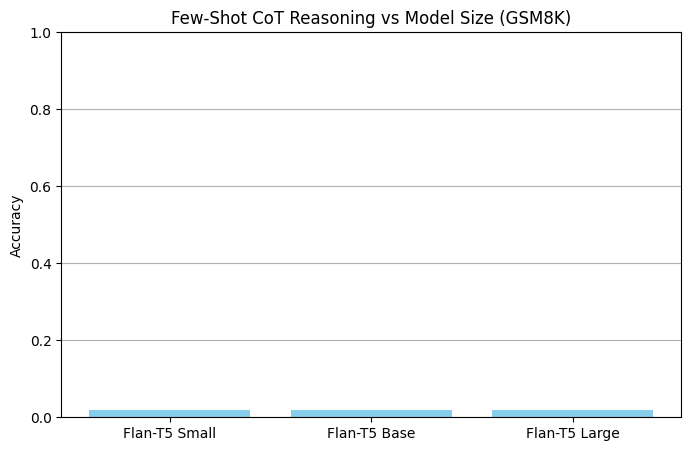

In [7]:
import matplotlib.pyplot as plt

model_ids = {
    "Flan-T5 Small": "google/flan-t5-small",
    "Flan-T5 Base": "google/flan-t5-base",
    "Flan-T5 Large": "google/flan-t5-large"
}

results = []
for label, model in model_ids.items():
    acc = evaluate_model_fewshot(model)
    results.append((label, acc))

# Plotting
labels = [r[0] for r in results]
scores = [r[1] for r in results]
x = range(len(labels))

plt.figure(figsize=(8,5))
plt.bar(x, scores, color="skyblue")
plt.xticks(x, labels)
plt.ylabel("Accuracy")
plt.title("Few-Shot CoT Reasoning vs Model Size (GSM8K)")
plt.ylim(0, 1.0)
plt.grid(True, axis='y')
plt.show()
